# Эксперимент 3. Дополнительные источники: Kaggle и агроэкономика

Два сюжета в одном ноутбуке.

Первый: подключить датасет с Kaggle. Это требует ключей, поэтому ноутбук сначала проверяет,
настроены ли они, и без них просто пропускает соответствующие ячейки, не роняя всё остальное.

Второй: добавить к погоде показатели, которые к погоде отношения не имеют — внесение удобрений,
долю орошаемых земель, долю сельского хозяйства в ВВП. Гипотеза в том, что рост урожайности
за двадцать лет объясняется ими куда лучше, чем метеорологией.

In [1]:
import sys
sys.path.insert(0, "..")

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

from ingestion import open_datasets as od

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def loyo(df, cols, target="yield_t_ha"):
    model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    X, y = df[cols], df[target]
    pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    return {"MAE": mean_absolute_error(y, pred), "R2": r2_score(y, pred), "pred": pred}

## Часть 1. Агроэкономические показатели

Все показатели из той же базы World Bank, что и урожайность. Годовые ряды, никаких ключей.

In [2]:
YEAR_START, YEAR_END = 2000, 2023

INDICATORS = {
    "fertilizer_kg_ha": "AG.CON.FERT.ZS",   # внесение удобрений, кг на га пашни
    "irrigated_share":  "AG.LND.IRIG.AG.ZS", # доля орошаемых земель, %
    "agri_land_share":  "AG.LND.AGRI.ZS",    # доля сельхозземель, %
    "agri_gdp_share":   "NV.AGR.TOTL.ZS",    # доля сельского хозяйства в ВВП, %
}

series = {}
for name, code_ in INDICATORS.items():
    try:
        series[name] = od.worldbank_indicator(code_, "RUS", YEAR_START, YEAR_END)
        print(f"{name:20s} {len(series[name]):3d} значений")
    except Exception as e:
        print(f"{name:20s} пропущен: {e}")

econ = pd.DataFrame(series)
econ.tail()

fertilizer_kg_ha     пропущен: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=30)
irrigated_share        8 значений
agri_land_share       24 значений
agri_gdp_share        24 значений


,irrigated_share,agri_land_share,agri_gdp_share
2019,NaN,13.158436,3.530303
2020,NaN,13.158436,4.006352
2021,NaN,13.158436,3.671564
2022,NaN,13.158436,3.418909
2023,NaN,13.171076,3.019393


In [3]:
yield_series = od.worldbank_indicator("AG.YLD.CREL.KG", "RUS", YEAR_START, YEAR_END) / 1000
yield_series.name = "yield_t_ha"

daily = od.nasa_power_daily(45.9, 39.2, date(YEAR_START, 1, 1), date(YEAR_END, 12, 31))
weather = od.growing_season_features(daily, YEAR_START, YEAR_END)

df = weather.join(econ, how="left").join(yield_series, how="inner")
# Экономические ряды публикуются с задержкой, последние годы часто пустые.
# Интерполируем внутри и протягиваем края: показатели меняются медленно и монотонно.
df[list(econ.columns)] = df[list(econ.columns)].interpolate().ffill().bfill()
df = df.dropna()
print(f"выборка: {len(df)} лет, признаков: {df.shape[1] - 1}")
df.head()

выборка: 24 лет, признаков: 10


,mean_t2m,sum_precip,mean_radiation,mean_humidity,hot_days_over_30,max_t2m,dry_days,irrigated_share,agri_land_share,agri_gdp_share,yield_t_ha
year,,,,,,,,,,,
2000,14.175182,300.33,18.791387,72.556642,11,37.03,89,2.069067,13.256669,5.751716,1.5614
2001,14.434307,290.34,17.782263,70.649124,13,36.22,89,2.069067,13.239022,5.875722,1.9347
2002,14.919489,140.96,19.675182,65.670073,18,39.01,107,2.052148,13.225798,5.565714,1.9691
2003,13.321752,116.00,20.141752,64.225182,15,37.48,109,2.099622,13.202934,5.502946,1.7774
2004,13.177591,306.56,18.012847,77.677299,0,29.41,84,2.097416,13.184602,4.904442,1.8765


### Что с чем связано

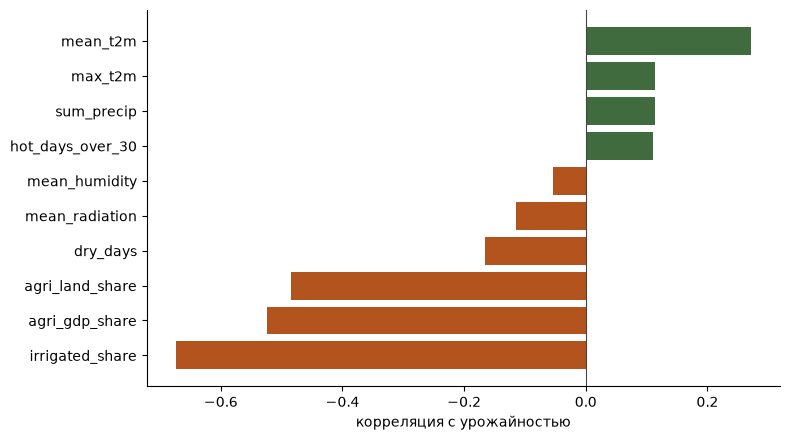

irrigated_share    -0.674
agri_gdp_share     -0.525
agri_land_share    -0.485
dry_days           -0.166
mean_radiation     -0.114
mean_humidity      -0.054
hot_days_over_30    0.111
sum_precip          0.113
max_t2m             0.114
mean_t2m            0.272
Name: yield_t_ha, dtype: float64

In [4]:
corr = df.corr(numeric_only=True)["yield_t_ha"].drop("yield_t_ha").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#b3541e" if v < 0 else "#3f6b3f" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="#444441", linewidth=0.8)
ax.set_xlabel("корреляция с урожайностью")
plt.tight_layout(); plt.show()

corr.round(3)

Высокая корреляция здесь мало что доказывает: у большинства этих рядов есть собственный
тренд, и они коррелируют с урожайностью просто потому, что оба меняются во времени.
Это классическая ложная корреляция, поэтому дальше сравниваем именно качество прогноза.

In [5]:
WEATHER = ["mean_t2m", "sum_precip", "mean_radiation", "mean_humidity"]
ECON = [c for c in econ.columns if c in df.columns]

variants = {
    "только погода": WEATHER,
    "только агроэкономика": ECON,
    "погода и агроэкономика": WEATHER + ECON,
    "только год (тренд)": None,
}

rows = []
for name, cols in variants.items():
    if cols is None:
        tmp = df.copy(); tmp["year_num"] = tmp.index
        r = loyo(tmp, ["year_num"])
    else:
        r = loyo(df, cols)
    rows.append({"набор": name, "MAE": r["MAE"], "R2": r["R2"]})

pd.DataFrame(rows).set_index("набор").round(3)

,MAE,R2
набор,,
только погода,0.423,-0.191
только агроэкономика,0.306,0.295
погода и агроэкономика,0.353,0.076
только год (тренд),0.176,0.770


Строка «только год» — важная. Это модель, которой вообще не дали данных, кроме номера года:
она умеет только продолжать тренд. Если она обходит модель на погоде, значит погодные признаки
в годовом разрешении не добавляют почти ничего сверх тренда, и всё, что мы принимали за прогноз,
было экстраполяцией.

## Часть 2. Датасет с Kaggle

Дальше нужны ключи. Заведите токен в профиле Kaggle (Account, кнопка Create New API Token),
скачается файл `kaggle.json`, оттуда возьмите значения:

```bash
export KAGGLE_USERNAME=ваш_логин
export KAGGLE_KEY=ключ_из_файла
```

и перезапустите ноутбук. Без ключей ячейки ниже просто напишут, что пропускают работу.

In [6]:
if not od.kaggle_credentials_available():
    print("Ключей Kaggle нет — часть 2 пропускается.")
    print("Всё, что выше, уже посчитано и не зависит от этой части.")
else:
    print("Ключи найдены, можно качать датасеты.")

Ключей Kaggle нет — часть 2 пропускается.
Всё, что выше, уже посчитано и не зависит от этой части.


In [7]:
# Датасет по урожайности культур в разрезе стран и лет.
# Если конкретный датасет удалят или переименуют, подставьте любой другой
# в формате "владелец/название" — дальнейший код от этого не зависит.
KAGGLE_DATASET = "patelris/crop-yield-prediction-dataset"

kaggle_df = None
if od.kaggle_credentials_available():
    try:
        kaggle_df = od.kaggle_dataset(KAGGLE_DATASET)
        print(f"загружено: {kaggle_df.shape[0]} строк, {kaggle_df.shape[1]} колонок")
        display(kaggle_df.head())
    except Exception as e:
        print(f"не получилось: {e}")
        print("Проверьте название датасета и то, что вы приняли его условия на сайте Kaggle.")

In [8]:
if kaggle_df is not None:
    print("колонки:", list(kaggle_df.columns))
    lowered = {c.lower(): c for c in kaggle_df.columns}
    if "area" in lowered and "year" in lowered:
        area_col, year_col = lowered["area"], lowered["year"]
        russia = kaggle_df[kaggle_df[area_col].astype(str).str.contains("Russia", case=False, na=False)]
        print(f"\nстрок по России: {len(russia)}")
        display(russia.head())

### Зачем вообще сравнивать источники

Один и тот же показатель в разных базах часто отличается: разная методика, разные годы
пересмотра, разный состав культур в агрегате. Если ряды из Kaggle и World Bank разойдутся,
это не значит, что один из них неправильный — это значит, что они считают разное, и в отчёте
обязательно нужно указывать, какой именно источник использован.

## Итог

Главный результат этого ноутбука обычно неприятный: модель, знающая только номер года,
оказывается сопоставимой с моделью на погодных признаках. Это не повод выбросить погоду —
это повод признать, что в годовом разрешении по стране погодный сигнал тонет в тренде
агротехники, и для содержательного прогноза нужны данные более мелкого разрешения:
по регионам и внутри сезона, а не одна цифра на страну в год.